# Set 11 - PCA und Merkmalsreduktion

Wir erzeugen korrelierte Sensordaten aus nur drei verborgenen Einflussgrößen. Obwohl die Tabelle viele Spalten besitzt, steckt die wesentliche Struktur deshalb in wenigen Dimensionen.

## Lernziele

- Feature Extraction und Feature Selection unterscheiden
- PCA nur auf Trainingsdaten anpassen
- Explained Variance, Loadings und Rekonstruktionsfehler lesen
- die Zahl der Komponenten begründet wählen
- PCA als Vorverarbeitung in einer überwachten Pipeline einsetzen

Die Zielvariable in diesem Notebook dient erst im letzten Abschnitt zur Bewertung einer nachgelagerten Klassifikation. PCA selbst sieht sie nie.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.feature_selection import VarianceThreshold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
plt.style.use("seaborn-v0_8-whitegrid")


## 1. Synthetische Prozessdaten erzeugen

Drei nicht direkt beobachtete Faktoren beeinflussen mehrere Sensoren. Einige Messgrößen sind fast Kopien voneinander, eine Spalte ist nahezu konstant und weitere Spalten enthalten überwiegend Rauschen. Die stark unterschiedlichen Einheiten sind absichtlich gewählt.


In [2]:
n_samples = 900
latent = rng.normal(size=(n_samples, 3))
z1, z2, z3 = latent.T

X = pd.DataFrame({
    "temperatur_c": 45 + 5.0*z1 + 0.4*rng.normal(size=n_samples),
    "temperatur_2_c": 44 + 4.8*z1 + 0.5*rng.normal(size=n_samples),
    "druck_kpa": 220 + 24*z1 - 12*z2 + 2*rng.normal(size=n_samples),
    "durchfluss_l_min": 70 + 9*z2 + 1.2*rng.normal(size=n_samples),
    "ventilstellung_pct": 50 + 11*z2 + 3*z3 + rng.normal(size=n_samples),
    "vibration_rms": 2.5 + 0.7*z3 + 0.08*rng.normal(size=n_samples),
    "vibration_peak": 8 + 2.1*z3 + 0.25*rng.normal(size=n_samples),
    "leistung_kw": 120 + 8*z1 + 10*z2 + 2*z3 + 1.5*rng.normal(size=n_samples),
    "rauschen_1": rng.normal(size=n_samples),
    "rauschen_2": rng.normal(size=n_samples),
    "rauschen_3": rng.normal(size=n_samples),
    "fast_konstant": 1 + 0.002*rng.normal(size=n_samples),
})

# Nur für den späteren überwachten Vergleich.
y_demo = (1.2*z1 - 0.9*z2 + 0.7*z3 + 0.8*rng.normal(size=n_samples) > 0).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_demo, test_size=0.25, stratify=y_demo, random_state=RANDOM_STATE
)
print("Training:", X_train.shape, "Test:", X_test.shape)
display(X_train.head())
display(X_train.describe().T[["mean", "std", "min", "max"]].round(3))


Training: (675, 12) Test: (225, 12)


,temperatur_c,temperatur_2_c,druck_kpa,durchfluss_l_min,ventilstellung_pct,vibration_rms,vibration_peak,leistung_kw,rauschen_1,rauschen_2,rauschen_3,fast_konstant
24,40.168587,39.554694,194.045723,75.333092,56.175866,2.536729,8.639274,119.627559,0.870953,0.520421,0.035442,1.003431
540,48.332477,46.698475,233.310034,68.211431,54.571879,2.985414,9.819972,125.460687,0.620017,-0.879532,-0.596413,0.997471
875,43.465160,43.511658,201.834645,82.034712,70.668462,3.456853,11.490457,132.532926,0.932067,-0.049514,0.409843,0.998302
299,40.554762,40.021397,192.705691,72.093484,51.926638,1.281806,4.967777,115.680929,-0.895280,1.512483,-1.397387,0.999629
877,40.143221,39.007735,196.365212,71.473234,49.295933,2.616808,8.063030,108.467328,-1.335267,0.146999,-0.271926,0.998470


,mean,std,min,max
temperatur_c,45.010,5.077,30.203,59.489
temperatur_2_c,43.969,4.914,29.558,57.070
druck_kpa,220.803,27.265,148.315,310.722
durchfluss_l_min,69.318,9.060,41.185,94.429
ventilstellung_pct,48.996,11.633,13.960,83.650
vibration_rms,2.450,0.724,0.438,4.498
vibration_peak,7.871,2.182,1.770,14.048
leistung_kw,119.041,12.962,80.579,167.222
rauschen_1,-0.054,0.998,-3.119,3.126
rauschen_2,-0.019,1.014,-3.083,4.151


## 2. Warum Skalierung vor PCA wichtig ist

PCA sucht Richtungen maximaler Varianz. Ohne Skalierung würden Sensoren mit großen Zahlenwerten und Einheiten wie kPa oder kW die Komponenten dominieren. Der StandardScaler wird ausschließlich auf den Trainingsdaten angepasst.


,Komponente,Varianzanteil,Kumuliert
0,1,0.265,0.265
1,2,0.252,0.516
2,3,0.150,0.666
3,4,0.089,0.755
4,5,0.082,0.837
5,6,0.081,0.917
6,7,0.078,0.996
7,8,0.001,0.997
8,9,0.001,0.998
9,10,0.001,0.999


Komponenten für mindestens 95 % erklärte Varianz: 7


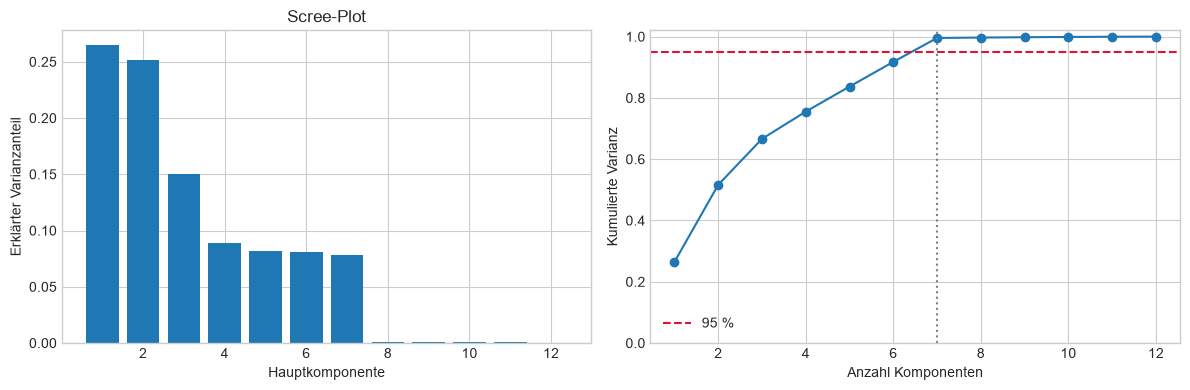

In [3]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

pca = PCA().fit(X_train_scaled)
explained = pd.DataFrame({
    "Komponente": np.arange(1, len(pca.explained_variance_ratio_) + 1),
    "Varianzanteil": pca.explained_variance_ratio_,
    "Kumuliert": np.cumsum(pca.explained_variance_ratio_),
})
display(explained.round(3))

k_95 = int(np.argmax(explained["Kumuliert"].to_numpy() >= 0.95) + 1)
print("Komponenten für mindestens 95 % erklärte Varianz:", k_95)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(explained["Komponente"], explained["Varianzanteil"])
axes[0].set(xlabel="Hauptkomponente", ylabel="Erklärter Varianzanteil", title="Scree-Plot")
axes[1].plot(explained["Komponente"], explained["Kumuliert"], marker="o")
axes[1].axhline(0.95, color="crimson", linestyle="--", label="95 %")
axes[1].axvline(k_95, color="grey", linestyle=":")
axes[1].set(xlabel="Anzahl Komponenten", ylabel="Kumulierte Varianz", ylim=(0, 1.02))
axes[1].legend()
plt.tight_layout(); plt.show()


## 3. Neue Merkmale und Loadings

Jede Hauptkomponente ist eine gewichtete Mischung aller standardisierten Originalmerkmale. Große positive oder negative Loadings zeigen, welche Spalten die jeweilige Richtung prägen. Das Vorzeichen einer Komponente kann sich mathematisch gleichwertig umdrehen.


Neue Form: (675, 7)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7
temperatur_c,0.555,-0.071,-0.012,0.014,0.004,-0.019,-0.033
temperatur_2_c,0.554,-0.073,-0.012,0.020,0.007,-0.016,-0.030
druck_kpa,0.472,-0.284,0.148,0.017,-0.007,-0.044,-0.058
durchfluss_l_min,0.049,0.498,-0.355,-0.016,0.013,0.059,0.067
ventilstellung_pct,0.051,0.555,-0.168,-0.014,0.012,0.033,0.048
vibration_rms,0.020,0.315,0.616,-0.010,-0.002,-0.071,-0.073
vibration_peak,0.025,0.316,0.614,-0.016,-0.006,-0.078,-0.075
leistung_kw,0.389,0.387,-0.177,-0.001,0.014,0.020,0.025
rauschen_1,-0.040,0.018,-0.058,0.431,0.816,-0.274,-0.259
rauschen_2,0.008,0.005,0.042,0.649,-0.255,-0.342,0.628


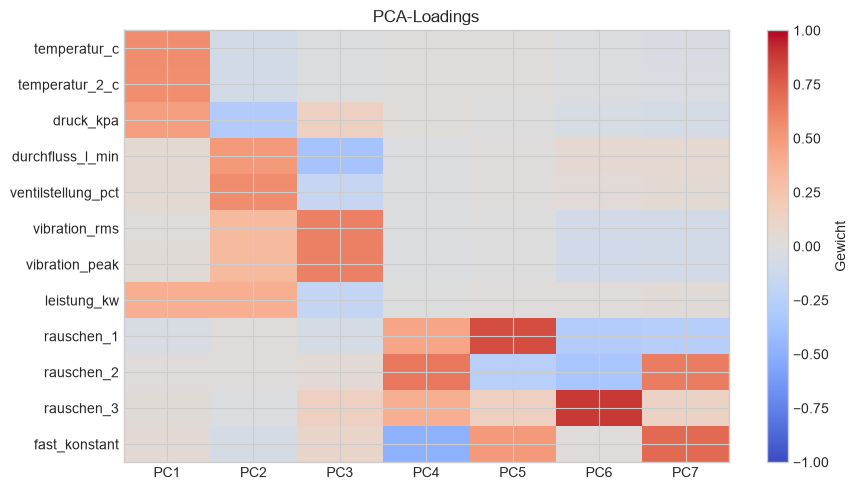

In [4]:
pca_reduced = PCA(n_components=0.95).fit(X_train_scaled)
Z_train = pca_reduced.transform(X_train_scaled)
Z_test = pca_reduced.transform(X_test_scaled)

component_names = [f"PC{i}" for i in range(1, pca_reduced.n_components_ + 1)]
loadings = pd.DataFrame(
    pca_reduced.components_.T,
    index=X.columns,
    columns=component_names,
)
print("Neue Form:", Z_train.shape)
display(loadings.round(3))

fig, ax = plt.subplots(figsize=(9, 5))
image = ax.imshow(loadings, cmap="coolwarm", aspect="auto", vmin=-1, vmax=1)
ax.set_xticks(range(len(component_names)), component_names)
ax.set_yticks(range(len(loadings.index)), loadings.index)
ax.set_title("PCA-Loadings")
fig.colorbar(image, ax=ax, label="Gewicht")
plt.tight_layout(); plt.show()


## 4. Informationsverlust über Rekonstruktion sichtbar machen

Mit inverse_transform werden reduzierte Daten zurück in den standardisierten Originalraum projiziert. Wenige Komponenten ergeben eine kompakte Darstellung, aber einen größeren Rekonstruktionsfehler. Es gibt keinen universell richtigen Grenzwert.


,Komponenten,Kumulierte Varianz,Rekonstruktions-RMSE
0,1,0.265,0.829
1,2,0.516,0.681
2,3,0.666,0.575
3,5,0.837,0.406
4,8,0.997,0.056
5,12,1.000,0.000


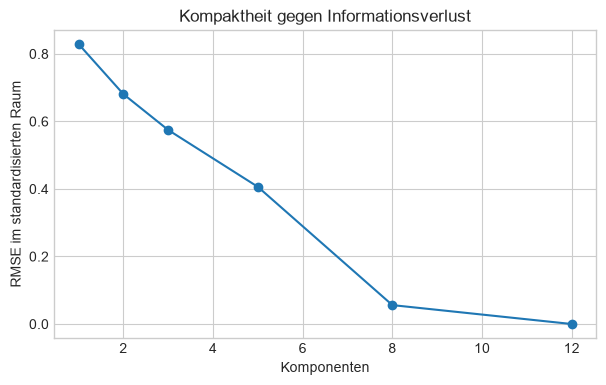

In [5]:
rows = []
max_components = X_train.shape[1]
for k in [1, 2, 3, 5, 8, max_components]:
    model = PCA(n_components=k).fit(X_train_scaled)
    reconstructed = model.inverse_transform(model.transform(X_test_scaled))
    rmse = np.sqrt(np.mean((X_test_scaled - reconstructed)**2))
    rows.append({
        "Komponenten": k,
        "Kumulierte Varianz": model.explained_variance_ratio_.sum(),
        "Rekonstruktions-RMSE": rmse,
    })

reconstruction = pd.DataFrame(rows)
display(reconstruction.round(3))
reconstruction.plot(
    x="Komponenten", y="Rekonstruktions-RMSE",
    marker="o", legend=False, figsize=(7, 4)
)
plt.ylabel("RMSE im standardisierten Raum")
plt.title("Kompaktheit gegen Informationsverlust")
plt.show()


## 5. Feature Selection ist etwas anderes

VarianceThreshold entfernt vorhandene Spalten mit sehr kleiner Varianz. Eine einfache Korrelationsregel entfernt anschließend stark redundante Originalmerkmale. Anders als PCA bleiben die Namen und ihre fachliche Bedeutung erhalten.

Achtung: Ein Varianzgrenzwert hängt von der Maßeinheit ab. Außerdem kann ein fast konstantes Merkmal für eine spätere Zielvariable trotzdem wichtig sein. Ohne y wird nur die Struktur von X bewertet.


In [6]:
variance_selector = VarianceThreshold(threshold=0.001)
variance_selector.fit(X_train)
kept_after_variance = X_train.columns[variance_selector.get_support()].tolist()
removed_by_variance = X_train.columns[~variance_selector.get_support()].tolist()

corr = X_train[kept_after_variance].corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
removed_by_correlation = [
    column for column in upper.columns if (upper[column] > 0.95).any()
]
selected_features = [
    column for column in kept_after_variance if column not in removed_by_correlation
]

print("Wegen geringer Varianz entfernt:", removed_by_variance)
print("Wegen hoher Korrelation entfernt:", removed_by_correlation)
print("Verbleibende Originalmerkmale:", selected_features)


Wegen geringer Varianz entfernt: ['fast_konstant']
Wegen hoher Korrelation entfernt: ['temperatur_2_c', 'ventilstellung_pct', 'vibration_peak']
Verbleibende Originalmerkmale: ['temperatur_c', 'druck_kpa', 'durchfluss_l_min', 'vibration_rms', 'leistung_kw', 'rauschen_1', 'rauschen_2', 'rauschen_3']


## 6. PCA in einer überwachten Pipeline verwenden

Nun wird geprüft, ob die kompaktere Darstellung einer späteren Klassifikation hilft. Die Pipeline lernt Standardisierung und PCA in jedem Cross-Validation-Fold neu. Dadurch fließen weder Validierungs- noch Testdaten in die Transformation ein.


In [7]:
models = {
    "Alle Merkmale": Pipeline([
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(max_iter=2000)),
    ]),
    "PCA mit 95 % Varianz": Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95)),
        ("classifier", LogisticRegression(max_iter=2000)),
    ]),
}

comparison = []
for name, model in models.items():
    cv = cross_validate(
        model, X_train, y_train, cv=5,
        scoring={"Accuracy": "accuracy", "F1": "f1"}
    )
    model.fit(X_train, y_train)
    prediction = model.predict(X_test)
    comparison.append({
        "Modell": name,
        "CV-Accuracy": cv["test_Accuracy"].mean(),
        "CV-F1": cv["test_F1"].mean(),
        "Test-Accuracy": accuracy_score(y_test, prediction),
        "Test-F1": f1_score(y_test, prediction),
        "Eingabedimension": (
            model.named_steps["pca"].n_components_
            if "pca" in model.named_steps else X_train.shape[1]
        ),
    })

display(pd.DataFrame(comparison).round(3))


,Modell,CV-Accuracy,CV-F1,Test-Accuracy,Test-F1,Eingabedimension
0,Alle Merkmale,0.844,0.841,0.849,0.832,12
1,PCA mit 95 % Varianz,0.844,0.841,0.849,0.833,7


## Fazit

- PCA erzeugt neue, orthogonale Merkmale und erhält möglichst viel lineare Varianz.
- Standardisierung und Fit nur auf Trainingsdaten sind entscheidend.
- Explained Variance ist eine Strukturmetrik, kein Beweis für gute Vorhersagen.
- Feature Selection behält Originalspalten; Feature Extraction ersetzt sie durch neue Komponenten.
- Eine Reduktion ist dann nützlich, wenn sie Visualisierung, Laufzeit, Robustheit oder das nachgelagerte Modell tatsächlich verbessert.
